In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")

# REVERSE TEMP for annealing
# supposed to be 1/10 if we're going with the right nomenclature 
# so supposed to be reversetemp
# S = 30
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            # NOTE: scaled by reverse temp
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    params = np.asarray(params)
    u = np.zeros_like(params)

    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])

    return u

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [21]:
param_ranges = [                                                                                                                                        
    (5.6, 6.4),   # logm1                                                                                                                               
    (0.8, 1.3),   # logm2                                                                                                                               
    (0.3, 0.99),  # a                                                                                                                                   
    (8.0, 11.0),  # p0                                                                                                                                  
    (0.2, 0.5),   # e0                                                                                                                                  
]                                                                                                                                                       
prior_lo = np.array([r[0] for r in param_ranges])                                                                                                       
prior_hi = np.array([r[1] for r in param_ranges])                                                                                                       
true_pt   = np.array([6.0, 1.0, 0.7, 9.0, 0.4])                                                                                                         
N_SCAN    = 100   

endpoints = {                                                                                                                                         
    # 'start (4_seed)': np.array([6.03302293, 1.12261954, 0.69265393, 9.04744717, 0.31691929]),                                                           
    'S=3':             np.array([6.04898077, 1.02323705, 0.79752621, 8.43772948, 0.38116196]),                                                           
    'S=10':            np.array([6.00409467, 1.00019579, 0.70970265, 8.94448855, 0.39934697]),                                                           
    'S=30':            np.array([6.0023143,  0.99992736, 0.70564538, 8.96781255, 0.3997671 ]), 
    'delS': np.array([6.00597255, 1.00197611, 0.71300743, 8.9263246 , 0.39821827])                                                          
}   


In [22]:
endpoints

{'S=3': array([6.04898077, 1.02323705, 0.79752621, 8.43772948, 0.38116196]),
 'S=10': array([6.00409467, 1.00019579, 0.70970265, 8.94448855, 0.39934697]),
 'S=30': array([6.0023143 , 0.99992736, 0.70564538, 8.96781255, 0.3997671 ]),
 'delS': array([6.00597255, 1.00197611, 0.71300743, 8.9263246 , 0.39821827])}

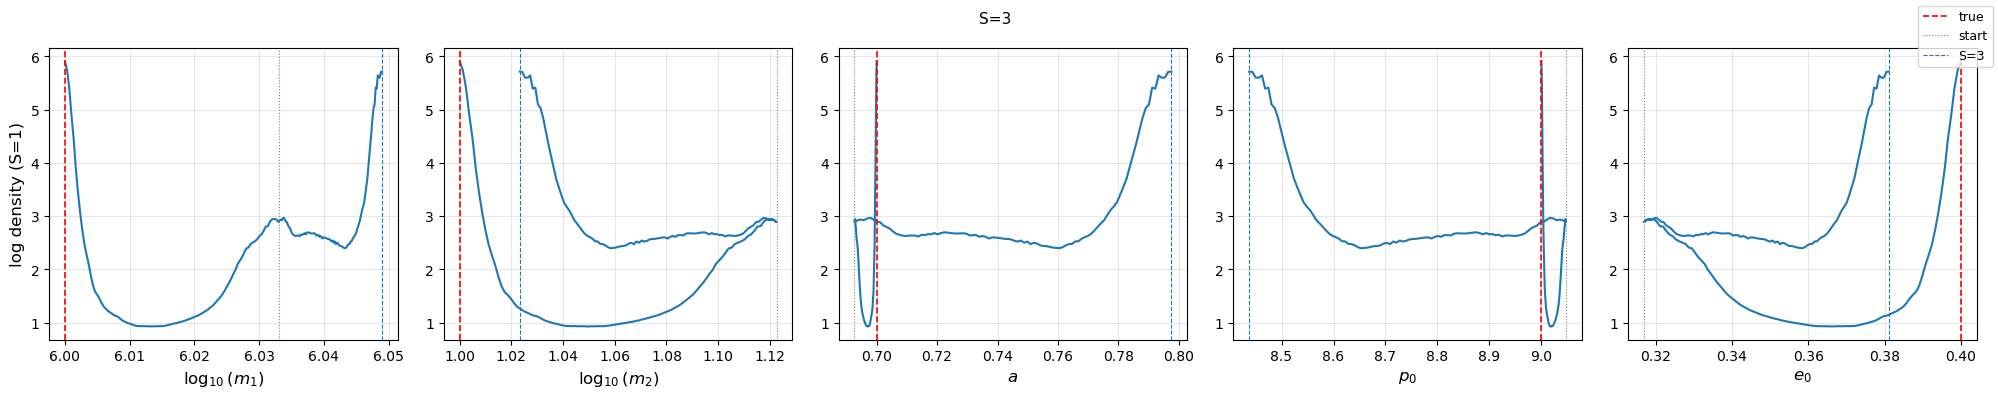

In [25]:
N_SCAN=100
start   = np.array([6.03302293, 1.12261954, 0.69265393, 9.04744717, 0.31691929])                                                                        
endpt   = endpoints['S=3'] 
seg1 = true_pt[:, np.newaxis] + np.linspace(0, 1, N_SCAN) * (start - true_pt)[:, np.newaxis]                                                            
seg2 = start[:, np.newaxis]   + np.linspace(0, 1, N_SCAN) * (endpt - start)[:, np.newaxis]                                                              
path = np.concatenate([seg1, seg2[:, 1:]], axis=1)                                                                                                      
                                                                                                                                                        
lds = log_density(path.T)                                                                                                                               
                                                                                                                                                        
labels_ = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']                                                                        
fig, axs = plt.subplots(1, 5, figsize=(20, 4))                                                                                                        
                                                                                                                                                        
for dim, ax in enumerate(axs):                                                                                                                          
    ax.plot(path[dim], lds, color='C0', lw=1.5)                                                                                                         
    ax.axvline(true_pt[dim], color='red',    lw=1.2, ls='--', label='true'  if dim==0 else None)                                                        
    ax.axvline(start[dim],   color='gray',   lw=0.8, ls=':',  label='start' if dim==0 else None)                                                        
    ax.axvline(endpt[dim],   color='C0',     lw=0.8, ls='--', label='S=3'    if dim==0 else None)                                                        
    ax.set_xlabel(labels_[dim], fontsize=12)                                                                                                            
    ax.grid(alpha=0.3)                                                                                                                                  
                                                                                                                                                        
axs[0].set_ylabel('log density', fontsize=12)                                                                                                     
fig.legend(*axs[0].get_legend_handles_labels(), loc='upper right', fontsize=9)                                                                          
fig.suptitle('S=3', fontsize=11)                                                                                       
plt.tight_layout()                                                                                                                                      
plt.show() 

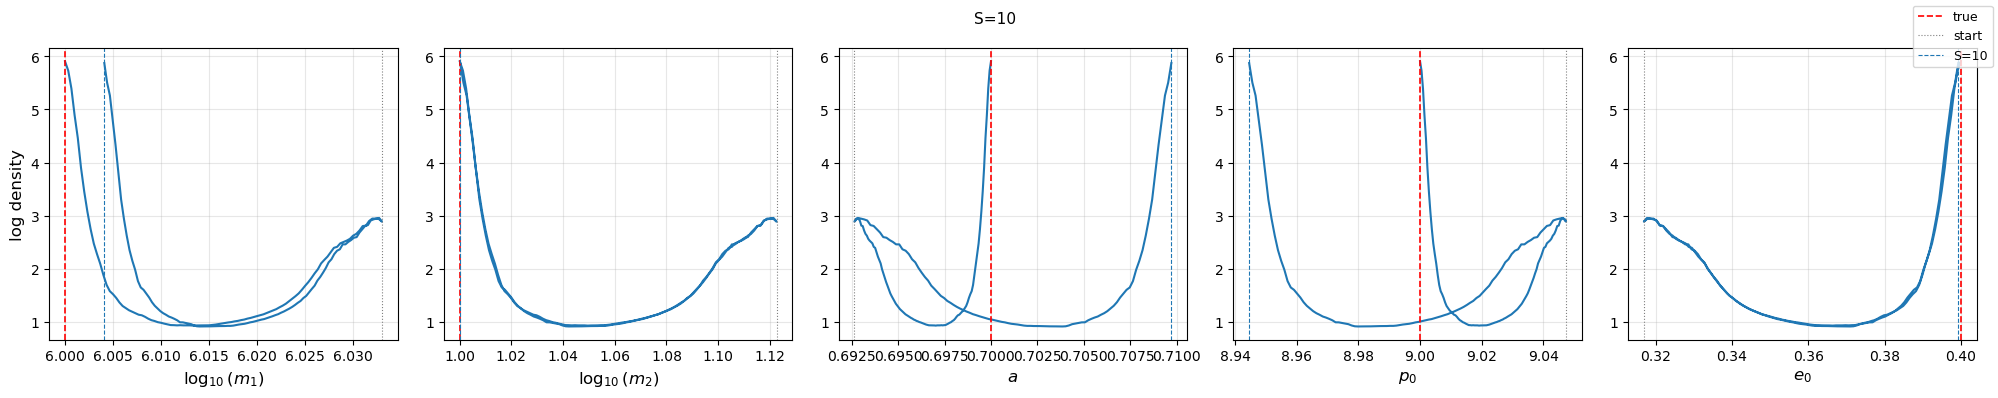

In [26]:
N_SCAN=100
start   = np.array([6.03302293, 1.12261954, 0.69265393, 9.04744717, 0.31691929])                                                                        
endpt   = endpoints['S=10'] 
seg1 = true_pt[:, np.newaxis] + np.linspace(0, 1, N_SCAN) * (start - true_pt)[:, np.newaxis]                                                            
seg2 = start[:, np.newaxis]   + np.linspace(0, 1, N_SCAN) * (endpt - start)[:, np.newaxis]                                                              
path = np.concatenate([seg1, seg2[:, 1:]], axis=1)                                                                                                      
                                                                                                                                                        
lds = log_density(path.T)                                                                                                                               
                                                                                                                                                        
labels_ = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']                                                                        
fig, axs = plt.subplots(1, 5, figsize=(20, 4))                                                                                                        
                                                                                                                                                        
for dim, ax in enumerate(axs):                                                                                                                          
    ax.plot(path[dim], lds, color='C0', lw=1.5)                                                                                                         
    ax.axvline(true_pt[dim], color='red',    lw=1.2, ls='--', label='true'  if dim==0 else None)                                                        
    ax.axvline(start[dim],   color='gray',   lw=0.8, ls=':',  label='start' if dim==0 else None)                                                        
    ax.axvline(endpt[dim],   color='C0',     lw=0.8, ls='--', label='S=10'    if dim==0 else None)                                                        
    ax.set_xlabel(labels_[dim], fontsize=12)                                                                                                            
    ax.grid(alpha=0.3)                                                                                                                                  
                                                                                                                                                        
axs[0].set_ylabel('log density', fontsize=12)                                                                                                     
fig.legend(*axs[0].get_legend_handles_labels(), loc='upper right', fontsize=9)                                                                          
fig.suptitle('S=10', fontsize=11)                                                                                       
plt.tight_layout()                                                                                                                                      
plt.show() 

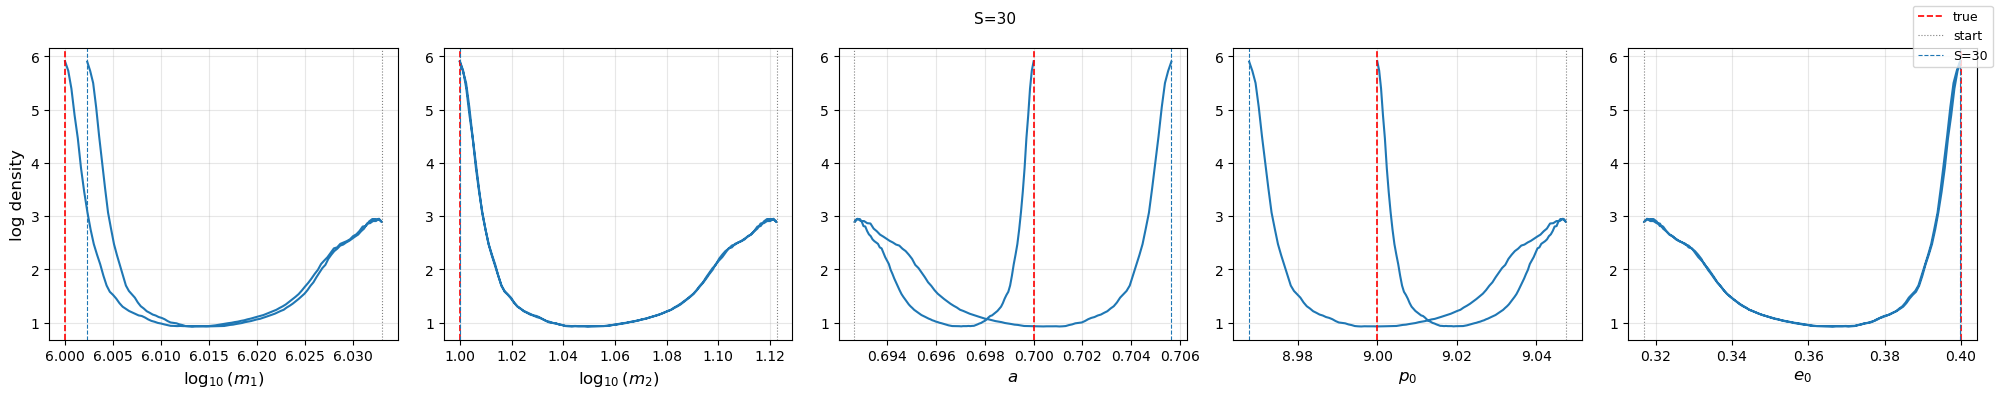

In [27]:
N_SCAN=100
start   = np.array([6.03302293, 1.12261954, 0.69265393, 9.04744717, 0.31691929])                                                                        
endpt   = endpoints['S=30'] 
seg1 = true_pt[:, np.newaxis] + np.linspace(0, 1, N_SCAN) * (start - true_pt)[:, np.newaxis]                                                            
seg2 = start[:, np.newaxis]   + np.linspace(0, 1, N_SCAN) * (endpt - start)[:, np.newaxis]                                                              
path = np.concatenate([seg1, seg2[:, 1:]], axis=1)                                                                                                      
                                                                                                                                                        
lds = log_density(path.T)                                                                                                                               
                                                                                                                                                        
labels_ = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']                                                                        
fig, axs = plt.subplots(1, 5, figsize=(20, 4))                                                                                                        
                                                                                                                                                        
for dim, ax in enumerate(axs):                                                                                                                          
    ax.plot(path[dim], lds, color='C0', lw=1.5)                                                                                                         
    ax.axvline(true_pt[dim], color='red',    lw=1.2, ls='--', label='true'  if dim==0 else None)                                                        
    ax.axvline(start[dim],   color='gray',   lw=0.8, ls=':',  label='start' if dim==0 else None)                                                        
    ax.axvline(endpt[dim],   color='C0',     lw=0.8, ls='--', label='S=30'    if dim==0 else None)                                                        
    ax.set_xlabel(labels_[dim], fontsize=12)                                                                                                            
    ax.grid(alpha=0.3)                                                                                                                                  
                                                                                                                                                        
axs[0].set_ylabel('log density', fontsize=12)                                                                                                     
fig.legend(*axs[0].get_legend_handles_labels(), loc='upper right', fontsize=9)                                                                          
fig.suptitle('S=30', fontsize=11)                                                                                       
plt.tight_layout()                                                                                                                                      
plt.show() 

In [ ]:
# load LHS best                                                                                                                                         
with open('/scratch/e1498138/lhs/lhs_snr32_checkpoints/lhs_snr32_final.pkl', 'rb') as f:                                                              
    _phys_pts, _lhs_ld = pickle.load(f)                                                                                                                 
lhs_best_phys = _phys_pts[np.argmax(_lhs_ld)]                                                                                                           
                                                                                                                                            
named_pts = {                                                                                                                                           
    'start':  np.array([6.03302293, 1.12261954, 0.69265393, 9.04744717, 0.31691929]),                                                                   
    'S3':     np.array([6.04898077, 1.02323705, 0.79752621, 8.43772948, 0.38116196]),                                                                   
    'S10':    np.array([6.00409467, 1.00019579, 0.70970265, 8.94448855, 0.39934697]),                                                                   
    'S30':    np.array([6.0023143,  0.99992736, 0.70564538, 8.96781255, 0.3997671 ]),                                                                   
    'LHS best': lhs_best_phys,                                                                                                                          
    'true':   true_pt,                                                                                                                              
}   

In [29]:
# compute logdens for all (S=1)                                                                                                                         
logdens = {name: log_density(pt.reshape(1,-1))[0] for name, pt in named_pts.items()}                                                                    
                                                                                                                                                        
all_pts = np.array(list(named_pts.values()))

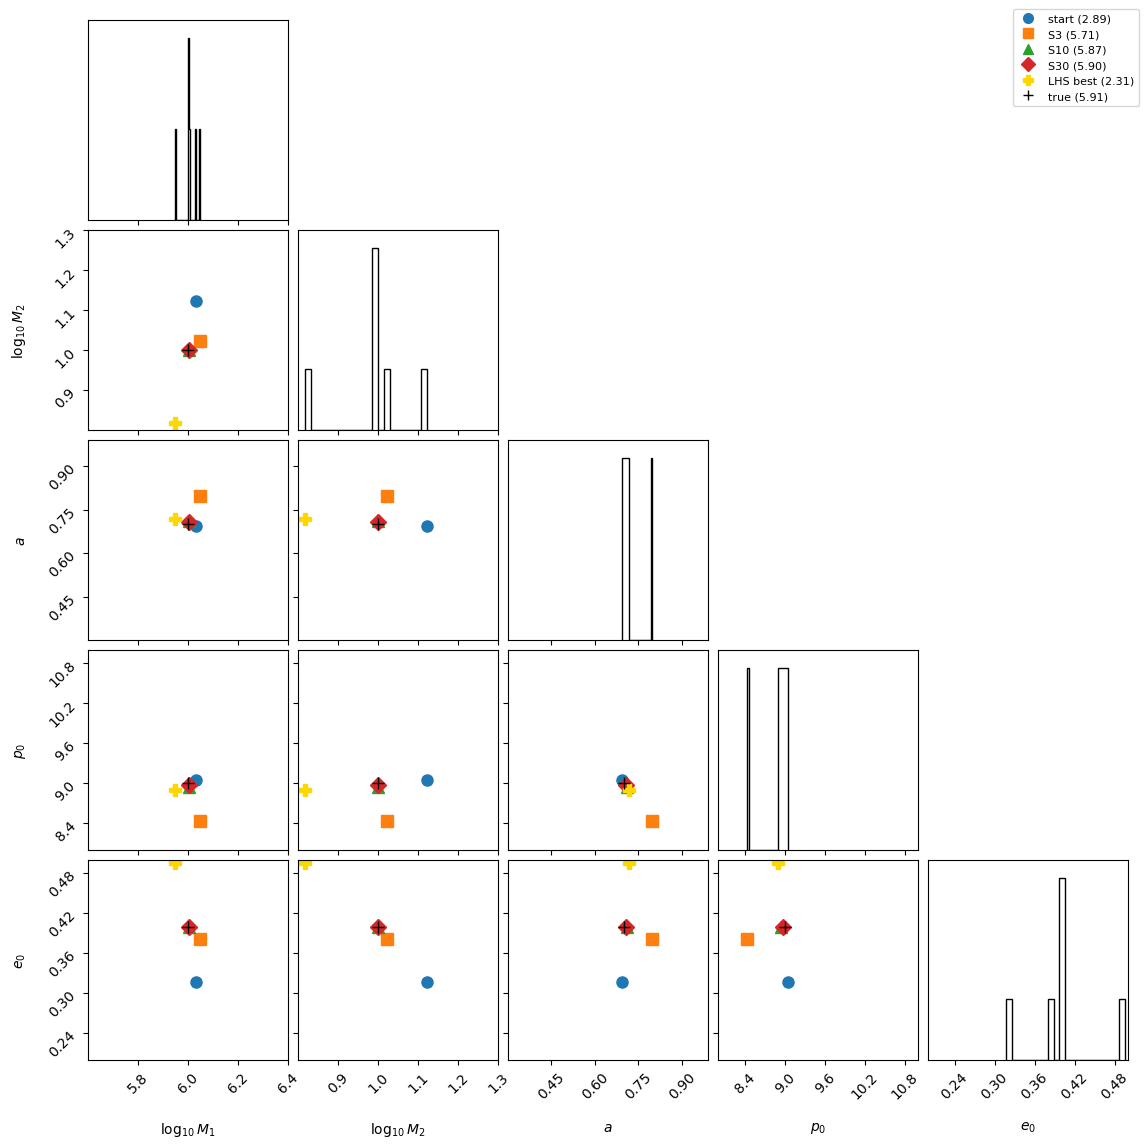

In [33]:
import corner
from matplotlib.lines import Line2D                                                                                                                     
ndim=5
labels = [r'$\log_{10}M_1$', r'$\log_{10}M_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                             
ranges = [                                                                                                                                              
    (5.6, 6.4),                                                                                                                                         
    (0.8, 1.3),                                                                                                                                         
    (0.3, 0.99),                                                                                                                                        
    (8.0, 11.0),                                                                                                                                        
    (0.2, 0.5),                                                                                                                                         
]   
fig = corner.corner(all_pts, labels=labels, show_titles=False,                                                                                          
                    plot_datapoints=False, plot_density=False, plot_contours=False,                                                                   
                    ranges=ranges)                                                                                                                      
                                                                                                                                                        
_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']                                                                                              
run_names = ['start', 'S3', 'S10', 'S30']                                                                                                               
_run_markers = ['o', 's', '^', 'D']                                                                                                                     
colors  = [_cycle[i % len(_cycle)] for i in range(len(run_names))] + ['gold', 'black']                                                                  
markers = _run_markers[:len(run_names)] + ['P', '+']                                                                                                    
                                                                                                                                                        
for (name, pt), c, mk in zip(named_pts.items(), colors, markers):                                                                                       
    corner.overplot_points(fig, pt.reshape(1, -1), color=c, marker=mk, ms=8)                                                                            
                                                                                                                                                        
# re-enforce ranges                                                                                                                                     
axes = np.array(fig.axes).reshape((ndim, ndim))                                                                                                         
for row in range(ndim):                                                                                                                                 
    for col in range(ndim):                                                                                                                             
        if col <= row:                                                                                                                                  
            axes[row, col].set_xlim(ranges[col])                                                                                                        
        if col < row:                                                                                                                                   
            axes[row, col].set_ylim(ranges[row])                                                                                                        
                                                                                                                                                        
handles = [                                                                                                                                             
    Line2D([0],[0], color=c, marker=mk, ls='', ms=7,                                                                                                    
            label=f"{name} ({logdens[name]:.2f})")                                                                                                       
    for (name, _), c, mk in zip(named_pts.items(), colors, markers)                                                                                     
]                                                                                                                                                       
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=8)                                                                 
plt.show()   